In [5]:
import numpy as np
import matplotlib.pyplot as plt
from vae_definition import VAE
import torch

[Text(0.5, 1.0, 'Loss per iteration'),
 Text(0.5, 0, 'Iteration'),
 Text(0, 0.5, 'Loss [reconstruction + Kullback Liebler div]')]

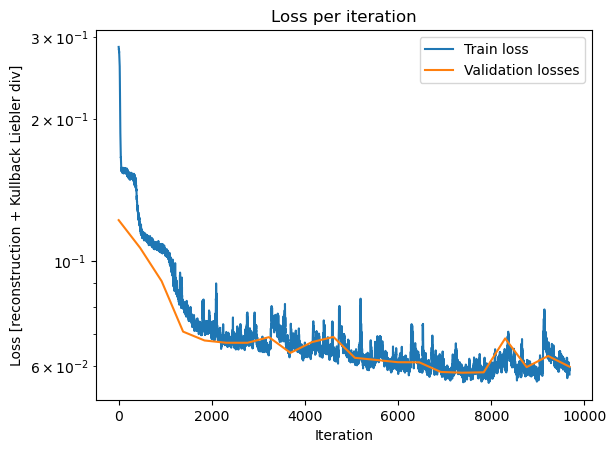

In [12]:
fig, ax = plt.subplots()
train_losses = np.load("vae_train_losses.npy")
val_losses = np.load("vae_val_losses.npy")
val_x = np.linspace(0, train_losses.shape[0], val_losses.shape[0])
ax.plot(train_losses, label="Train loss")
ax.plot(val_x, val_losses, label="Validation losses")
ax.legend()
ax.set(yscale="log")
ax.set(title="Loss per iteration", xlabel="Iteration", ylabel="Loss [reconstruction + Kullback Liebler div]")

torch.Size([100000, 48])
tensor([[ 1.7942e-08,  4.2923e-09,  4.7676e-04,  ...,  1.0000e+00,
         -2.7304e-01,  1.4127e+00],
        [ 9.6485e-06,  4.6465e-09,  3.4461e-04,  ...,  1.0000e+00,
          2.7848e-01,  1.2772e+00],
        [ 4.5437e-10,  4.6295e-09,  1.2970e-03,  ...,  1.0000e+00,
         -2.0578e-02,  1.4619e+00],
        ...,
        [ 1.2812e-11,  5.7436e-09, -6.1397e-04,  ...,  1.0000e+00,
         -2.5640e-01,  1.6233e+00],
        [ 6.8108e-09,  4.0448e-09, -1.2479e-04,  ...,  1.0000e+00,
         -3.0287e-01, -6.8985e-01],
        [ 3.3713e-06,  5.4545e-09, -1.1754e-03,  ...,  1.0000e+00,
         -2.8515e-01,  1.2095e+00]])


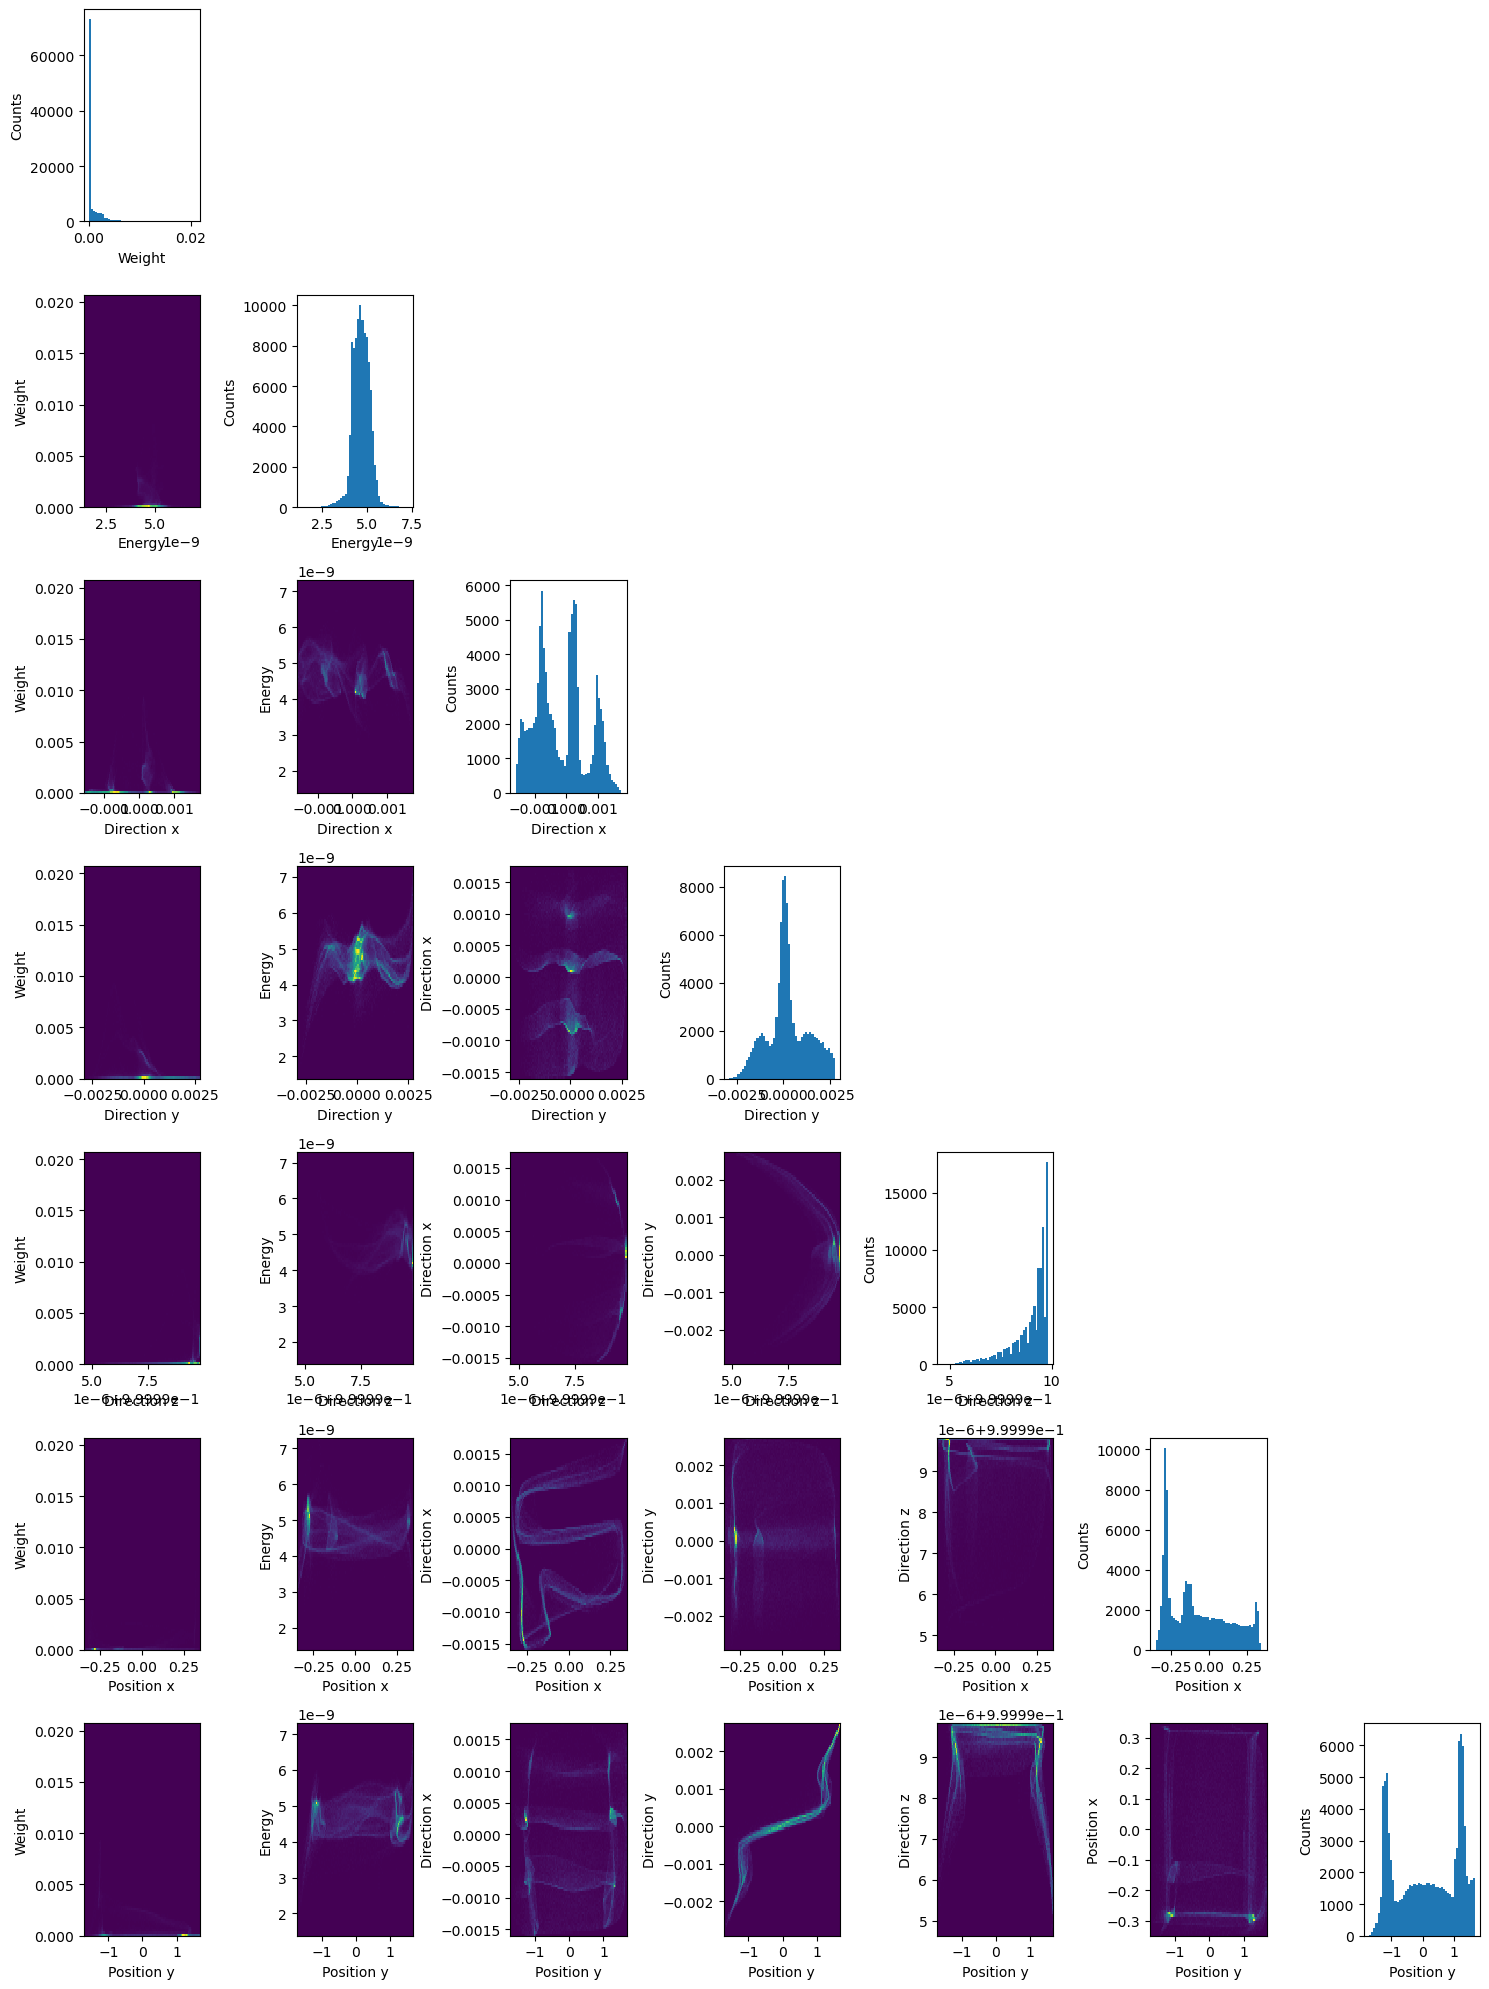

In [13]:
# sample_from_vae.py
device = "mps"

ckpt = torch.load("vae_best.pth", map_location=device)

vae = VAE().to(device)
vae.load_state_dict(ckpt["state_dict"])
vae.eval()

mins = ckpt["mins"].to(device)       
scales = ckpt["scales"].to(device)  


labels = ["Weight", "Energy", "Direction x", "Direction y", "Direction z", "Position x", "Position y"]
#labels = ["Angle theta", "Angle phi", "Position x", "Position y"]
with torch.no_grad():
    z = torch.randn(100000,48).to(device)  # sample 1000 latent vectors
    print(z.shape)
    samples = vae.decode(z)              # synthetic data in [0,1]
    samples = samples.clamp(0,1)
    samples = samples * scales + mins
samples = samples.cpu()
print(samples.cpu())
input_dim = 7
fig, ax = plt.subplots(ncols=input_dim, nrows=input_dim, figsize=(15,20))
for i in range(input_dim):
    for j in range(input_dim):
        if j>i:
            ax[i,j].set_axis_off()
            continue
        if j==i:
            try:
                ax[i,j].hist(samples[:,i], bins=50)
                ax[i,j].set(xlabel=labels[i], ylabel="Counts")
            except Exception as e:
                print(e)
                ax[i,j].set_axis_off()
            continue
        ax[i,j].hist2d(samples[:,i], samples[:,j], bins=100)
        ax[i,j].set(xlabel=labels[i], ylabel=labels[j])
plt.tight_layout()